### 이진 분류: 두가지 중 하나를 선택하는 분류

분류: 데이터를 보고 어떤 그룹에 속하는지 맞히는 것 -> 정보를 보고 범주를 예상하는 것 
       -ex) 합격/불합격, 정상/이상, 생존/사망

다중 분류: 범주가 3개 이상

예를 들어, 은행에서 고객의 정보를 가지고 "이 고객이 대출을 연체할까?" 를 예측할때
결과는 [연체한다]/[연체하지 않는다]로 두 게, 즉 이진분류인 상황

- 종속변수: 이때 우리가 예측하고 싶은 값 (y)
  ex)고객정보를 가지고 연체 여부를 판단할 경우에는 연체 여부가 종속변수(y)이다

- 독립변수: 종속변수를 예측하기 위해 사용하는 데이터
  ex) 고객의 나이, 소득, 대출금액, 신용점수 등 -> 이를 가지고 연체여부를 ㅇ측하나면 하나


In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [48]:
base_path = r"C:\kdt_0900_lsu\ml\resource\datasets"
file_name = r"titanic.csv"

file_path = os.path.join(base_path, file_name)

In [49]:
df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 타이타닉 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 설명 및 주요 값 예시 |
| :--- | :---: | :--- |
| **PassengerId** | `int64` | 승객 고유 번호 (1, 2, 3...) |
| **Survived** | `int64` | 생존 여부 (**0**: 사망 / **1**: 생존) |
| **Pclass** | `int64` | 객실 등급 (**1**: 1등석, **2**: 2등석, **3**: 3등석) |
| **Name** | `object` | 승객 이름 (호칭 포함: Mr, Mrs, Miss 등) |
| **Sex** | `object` | 성별 (`male`: 남성 / `female`: 여성) |
| **Age** | `float64` | 승객 나이 (결측치 존재) |
| **SibSp** | `int64` | 함께 탑승한 형제자매/배우자 수 (Siblings / Spouses) |
| **Parch** | `int64` | 함께 탑승한 부모/자녀 수 (Parents / Children) |
| **Ticket** | `object` | 티켓 번호 |
| **Fare** | `float64` | 탑승 요금 |
| **Cabin** | `object` | 객실 번호 (결측치 다수 존재) |
| **Embarked** | `object` | 탑승 항구 (**C**: Cherbourg, **Q**: Queenstown, **S**: Southampton) |

In [50]:
drop_columns = ["PassengerId","Name","Ticket","Cabin","Embarked"]
titanic_df = df.drop(drop_columns,axis=1)

In [51]:
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
888,0,3,female,NaN,1,2,23.4500
889,1,1,male,26.0,0,0,30.0000


## 1단계, 데이터 전처리

In [52]:
# 수치형:Age,Fare, SibSp, Parch
# 분류형: Survived, Pclass, sex


titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 48.9+ KB


In [53]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


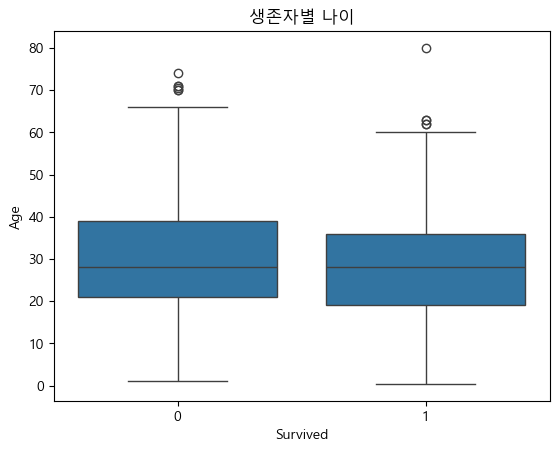

In [54]:
sns.boxplot(titanic_df, x="Survived",y="Age") 

plt.title("생존자별 나이")
plt.show()

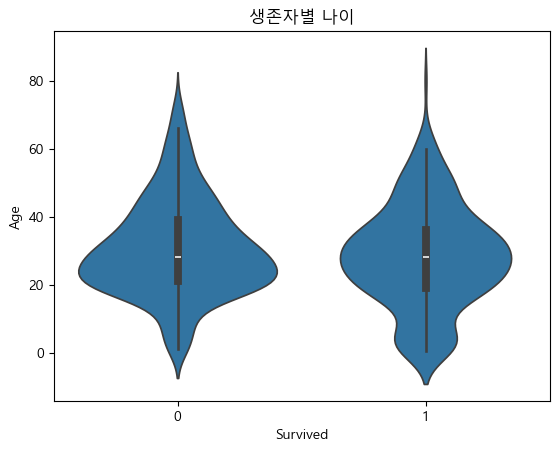

In [55]:
sns.violinplot(titanic_df, x="Survived", y="Age")
plt.title("생존자별 나이")
plt.show()

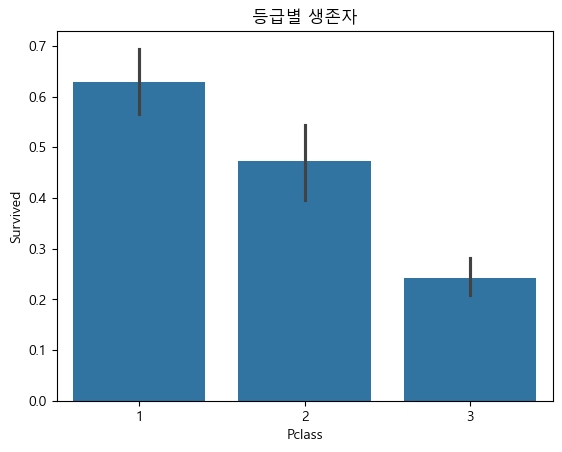

In [56]:
sns.barplot(titanic_df,x="Pclass", y="Survived")
plt.title("등급별 생존자")
plt.show()

In [57]:
titanic_df["Age"].fillna(titanic_df["Age"].median())

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [58]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 48.9+ KB


### 원-핫- 인코딩(One-Hot encoding)
- 글자나, 범주형(분류형) 데이터를 컴퓨터가 좋아하는 0과 1의 행렬구조로 변환하는 전처리 기술

In [59]:
# # pd.get_dummies
# titanic_df["Sex"].map(lambda gender:{"male":0, "female":1}{gender})

In [60]:
# pd.get_dummies
titanic_df["Sex"] = titanic_df["Sex"].map({"male":0, "female":1})

In [61]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500


# 파생변수

In [62]:
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,0,3,0,22.0,1,0,7.2500,2
1,1,1,1,38.0,1,0,71.2833,2
2,1,3,1,26.0,0,0,7.9250,1


## 상관관계 분석 및 다중공선성

In [63]:
corr_matrix = titanic_df.corr(numeric_only=True)
corr_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
Survived,1.000000,-0.338481,0.543351,-0.077221,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.131900,-0.369226,0.083081,0.018443,-0.549500,0.065997
Sex,0.543351,-0.131900,1.000000,-0.093254,0.114631,0.245489,0.182333,0.200988
Age,-0.077221,-0.369226,-0.093254,1.000000,-0.308247,-0.189119,0.096067,-0.301914
SibSp,-0.035322,0.083081,0.114631,-0.308247,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,0.245489,-0.189119,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.182333,0.096067,0.159651,0.216225,1.000000,0.217138
FamilySize,0.016639,0.065997,0.200988,-0.301914,0.890712,0.783111,0.217138,1.000000


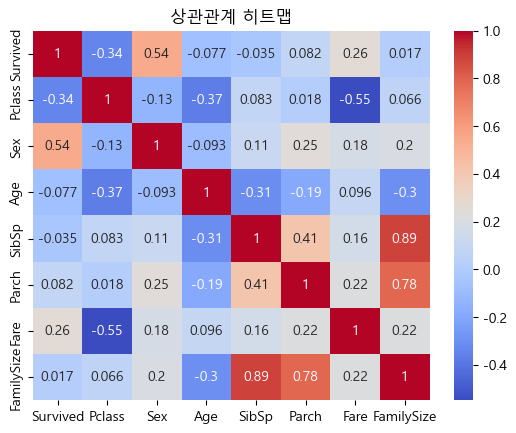

In [64]:
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("상관관계 히트맵")
plt.show()

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [66]:
X = titanic_df.drop("Survived", axis=1)
X.head(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,3,0,22.0,1,0,7.2500,2
1,1,1,38.0,1,0,71.2833,2
2,3,1,26.0,0,0,7.9250,1


In [67]:
y = titanic_df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [68]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif

MissingDataError: exog contains inf or nans

In [ ]:
X.shape

## VIF
- 한 독립변수가 다른 독립변수들에 의해 얼마나 잘 설명되는지 설명하는 값을 의미한다.
즉 독립변수와 독립변수와의 관계를 의미하며 다른 변수들과의 조합을 수치로 표현한 것이다.
## VIF 해석
- VIF<S: 문제 없음
- 5 <= VIF <= 10: 주의
- VIF > 10: 다중 공선성 의심(조치, 삭제, 고려기

In [69]:
titanic_df = titanic_df.drop(["SibSp", "Parch"], axis=1)

In [70]:
X = titanic_df.drop("Survived", axis=1)
X.head()

,Pclass,Sex,Age,Fare,FamilySize
0,3,0,22.0,7.2500,2
1,1,1,38.0,71.2833,2
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,2
4,3,0,35.0,8.0500,1


In [71]:
y = titanic_df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [72]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif

MissingDataError: exog contains inf or nans

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test. shape, y_train.shape, y_test.shape)

In [81]:
# 표준화 

scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [82]:
## 2단계, 모델분류

In [83]:
from sklearn.linear_model import LogisticRegression

In [84]:
lr = LogisticRegression()

In [85]:
## 3단계 

In [86]:
lr.fit(X_train_scalerd, y_train)

NameError: name 'X_train_scalerd' is not defined

In [87]:
## 4단계 모델 평가

In [88]:
train_score = lr.score(X_train_scaled, y_train)
test_score = lr.score(X_test_scaled, y_test)


print(f"훈련 데이터 정확도 점수: {train_score:.2f}")
print(f"테스트 데이터 정확도 점수: {test_score: .2f}")

NameError: name 'X_train_scaled' is not defined

In [ ]:
y_pred = lr
y_pred 

In [ ]:
print(f"모델의 예측 확률: {1r.predict_proba(X_test_scaled)[:51}")
print(f"모델의 예측 값: {y_pred[:5]}")
print(f"모델의 정답: {y_test.values[:5]}")

In [ ]:
print(f"테스트 정확도: {lr.score(X_train_scaled, y_train)}")
print(f"테스트 정확도: {accuracy_score(y_pred=y_pred, y_true=y_test)}")

### Roc-Curve
- 이진 분류 모델의 성능을 임계값을 기준에서 시각적으로 평가한 그래프
- x축(특이도) - TPR: 실제 양성 중 모델이 양성으로 맞춘 비율
- y축(민감도) - FPR: 실제 음성 중 모델이 양성으로 잘못 맞춘 비율


In [ ]:
# 각 가중치
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

In [ ]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features")
plt.title("각 컬럼의 가중치")
plt.show()

In [ ]:
worng_case = X_test[t_test]